In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import utils as U
import analysis_utils as auti
import file_utils as futi
import event_utils as euti


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )
importlib.reload( futi )
importlib.reload( euti )

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
%%time
skip_this = True
if skip_this == False:
    nsteps=None
    start_date = None 
    
    case, process_ncdata  = 'c153_topfix_ne240pg3_FMTHIST_xic_x02'   , False
    #case, process_ncdata  = 'c124_dyamond1_prod2'    , False
    #case , process_ncdata = 'xy-rdg-mm-front'    , True
    
    cases=[ 'cam77_dyamond1_prod1', 'c124_dyamond1_prod2',]
    cases=[ 'c153_topfix_ne240pg3_FMTHIST_xic_x02',  'c153_topfix_ne240pg3_FMTHIST_xic_x03',  'c153_topfix_ne240pg3_FMTHIST_xic_x04', ] #'cam77_dyamond1_prod1', 'c124_dyamond1_prod2',]
    #cases=[ 'c124_dyamond1_prod2',]
    #start_date = [2016,8,25,0]
    #nsteps=3*8  #31*8-1
    Al=[]
    for case in cases: 
        
        XX = futi.read_time_avg_case( case=case, nsteps=nsteps , start_date = start_date ) # , nsteps = 31*8 )
    



CPU times: user 7 μs, sys: 0 ns, total: 7 μs
Wall time: 11.4 μs


In [3]:
case_dic = [ 
    { 'case':'c153_topfix_ne240pg3_FMTHIST_xic_x02'  , 'start_date':[2004,8,99,0] , 'desc': 'ne240pg3 2004', } ,
    { 'case':'c153_topfix_ne240pg3_FMTHIST_xic_x03'  , 'start_date':[2007,8,99,0] , 'desc': 'ne240pg3 2007',  } ,
    { 'case':'c153_topfix_ne240pg3_FMTHIST_xic_x04'  , 'start_date':[2011,8,99,0] , 'desc': 'ne240pg3 2011',  } ,
    { 'case':'cam77_dyamond1_prod1'  , 'start_date':[2016,8,99,0] , 'desc': 'MPAS 3.75km - no deep scheme'  } ,
    { 'case':'c124_dyamond1_prod2'   , 'start_date':[2016,8,99,0] , 'desc': 'MPAS 3.75km - clubb+mf' , } ,
    ]


for c in case_dic:
    print( c['case'],c['start_date'] )
    

c153_topfix_ne240pg3_FMTHIST_xic_x02 [2004, 8, 99, 0]
c153_topfix_ne240pg3_FMTHIST_xic_x03 [2007, 8, 99, 0]
c153_topfix_ne240pg3_FMTHIST_xic_x04 [2011, 8, 99, 0]
cam77_dyamond1_prod1 [2016, 8, 99, 0]
c124_dyamond1_prod2 [2016, 8, 99, 0]


In [4]:
%%time
importlib.reload(futi)
importlib.reload(auti)
Al=[]
for c in case_dic: 
    case = c['case']
    start_date = c['start_date'] 
    nsteps=1 
    A = futi.read_case( case=case, nsteps=nsteps , start_date = start_date ) # , nsteps = 31*8 )

    """
    A.epwp=0.
    A.upwp=0.
    A.vpwp=0.
    A.tilt=0.
    A.fgf=0.
    A.rhoi=0.
    A.ze=0.
    A.pint=0.
    """
    if 'desc' in c:
        A['desc']=c['desc']
    else:
        A['desc']=c['case']
        
    
    Al.append(A)
    print( f"  ... Read {case} ")
    #zlev, lat, lon = A.zlev, A.lat, A.lon



  nsteps=1 
/glade/derecho/scratch/juliob/archive/c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-08-99-00000.nc /glade/derecho/scratch/juliob/archive/c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-08-99-00000.nc
 Dataset opened  , dtype of U,V float64 float64 
 Dataset opened  trimmed. -89.76 to  89.76 
Read subsetted X w open_mfdata_set  0.2012 seconds
extracted upwp,...U,V,T etc  0.0763 seconds
Vorticity calc  0.0342 seconds
X is present 
rho geopht pint ... calc  0.0704 seconds
rho calc ... epwp  0.0631 seconds
(1, 93, 192, 288)
(1, 93, 192, 288)
(1, 93, 192, 288)
(1, 93, 192, 288)
tilting calc  0.0590 seconds
this is Sphere_grad_vec in numerical_utils in HiRes_ana
dlat has been adjusted to account for FUCKED UP CRAPPY fv1x1 SCRIP FILE IN CESMDATA INPUTs!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
frontogenesis calc  0.1620 seconds
stability calc  0.0240 seconds
 

[2.0e-05 4.0e-05 1.0e-04 2.0e-04 3.0e-04 4.0e-04 6.0e-04 8.0e-04 1.0e-03
 1.2e-03 1.6e-03 2.0e-03 3.0e-03 4.0e-03 6.0e-03 8.0e-03 1.0e-02 1.2e-02
 2.0e-02 4.0e-02 1.0e-01 2.0e-01]
(192,)
(93, 192)
(93, 192)
(192,)
(93, 192)
(93, 192)
(192,)
(93, 192)
(93, 192)
(192,)
(58, 192)
(58, 192)
(192,)
(58, 192)
(58, 192)


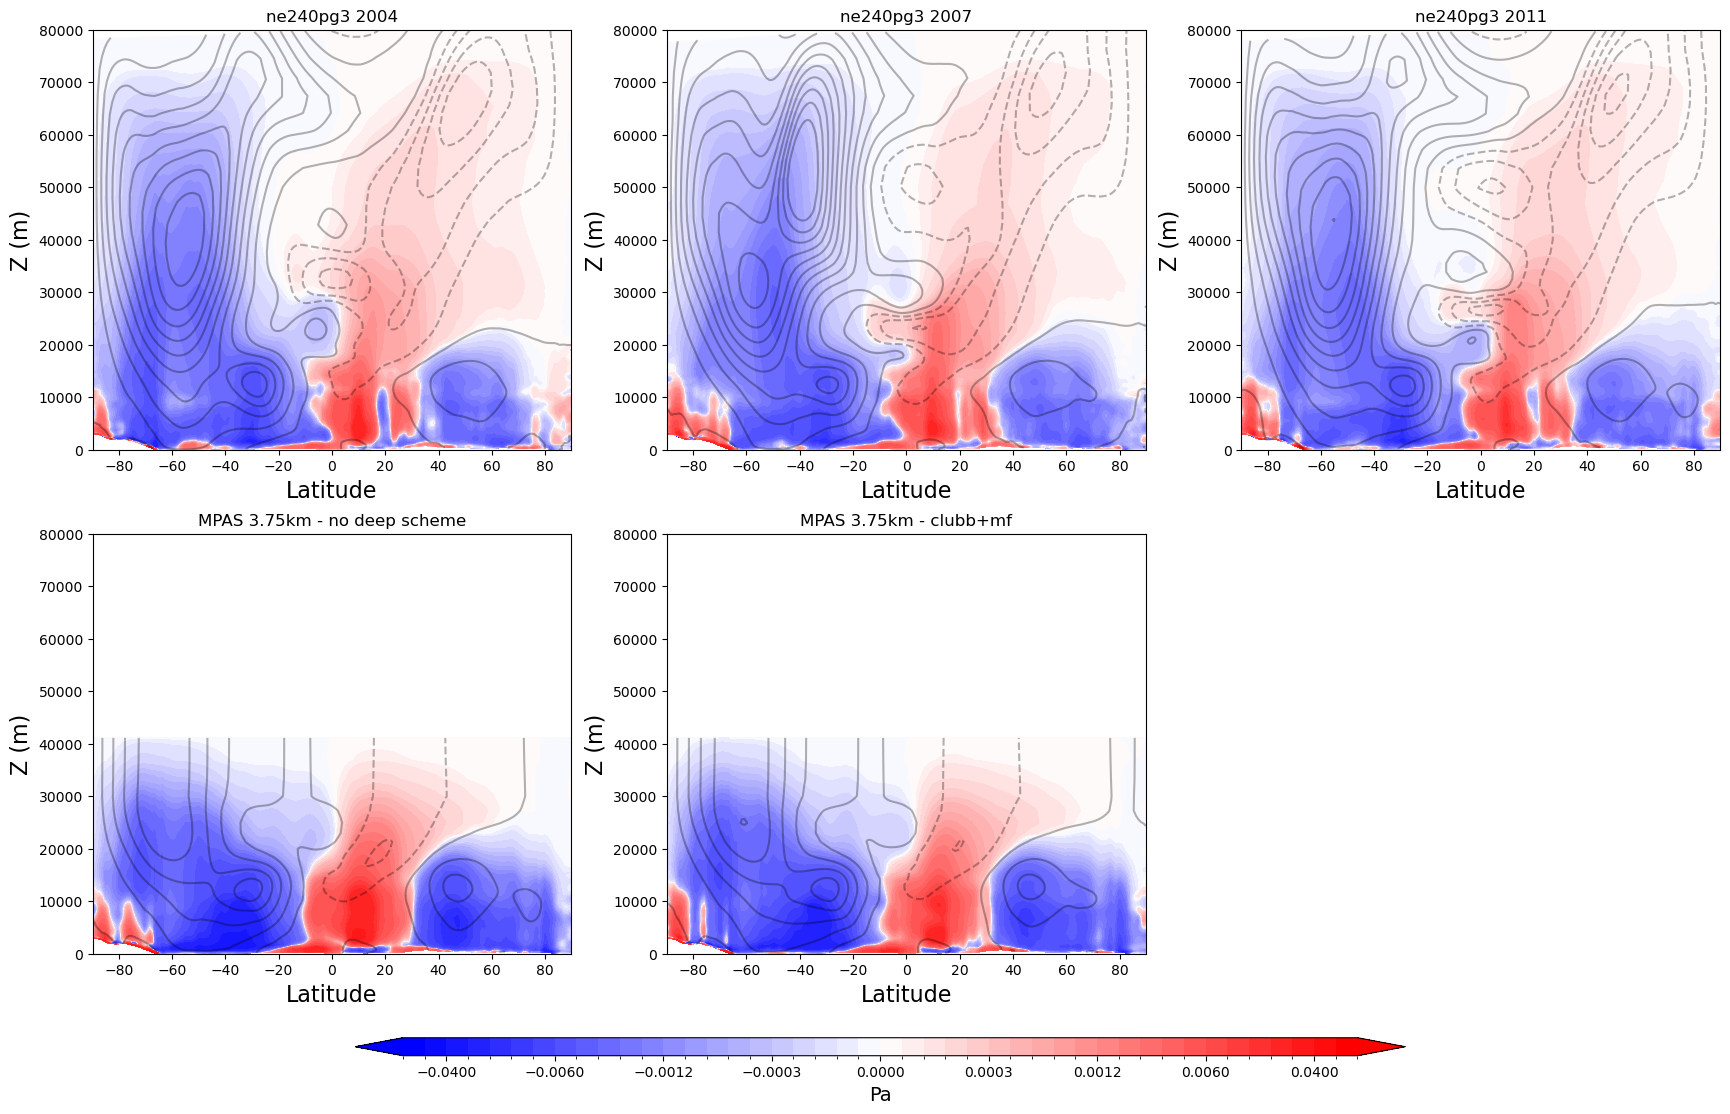

In [5]:



flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=0.2*np.asarray( flev )

print(flev)

flev2=np.flip( flev )
flev3 = np.concatenate( (-flev2, np.array([0]) , flev ))

cmap = plt.cm.bwr # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev3, ncolors=cmap.N, clip=False)




ulev=np.linspace(-100.,100.,num=21)
n=len(Al)
fig,axs=plt.subplots(2,n//2+1, figsize=( (n//2+1)*7 , 12 ) )
axs[1,2].axis('off')

axs=axs.flatten()
p=0
for A in Al:
    ax=axs[p]
    nt,nz,nx,ny=np.shape( A.zo )
    Lat = np.tile(A.lat[None,:], (nz, 1) )
    Zoo = np.mean( A.zo[0,:,:,:], axis=2 )
    print( np.shape(A.lat) )
    print( np.shape(Lat) )
    print( np.shape(Zoo) )
    
    #co=ax.contourf( A.lat, A.zlev, np.mean( A.rho_upwp[0,:,:,:], axis=2 ), levels=flev3, cmap=cmap , norm=norm, extend='both'  )
    #li=ax.contour( A.lat, A.zlev, np.mean( A.u[0,:,:,:], axis=2 ), levels=ulev, colors='black' , alpha=0.3)
    co=ax.contourf( Lat, Zoo, np.mean( A.rho_upwp[0,:,:,:], axis=2 ), levels=flev3, cmap=cmap , norm=norm, extend='both'  )
    li=ax.contour( Lat, Zoo, np.mean( A.u[0,:,:,:], axis=2 ), levels=ulev, colors='black' , alpha=0.3)
    ax.set_ylim(0.,80_000.)
    ax.set_title( A.desc )
    ax.set_ylabel( 'Z (m)' , fontsize=16 )
    ax.set_xlabel( 'Latitude', fontsize=16)
    #plt.colorbar(co)
    p=p+1

cax = fig.add_axes([0.25, 0.025, 0.50, 0.015])
cbar = fig.colorbar(
    co,
    cax=cax,
    orientation='horizontal')
cbar.set_label('Pa',fontsize=14)

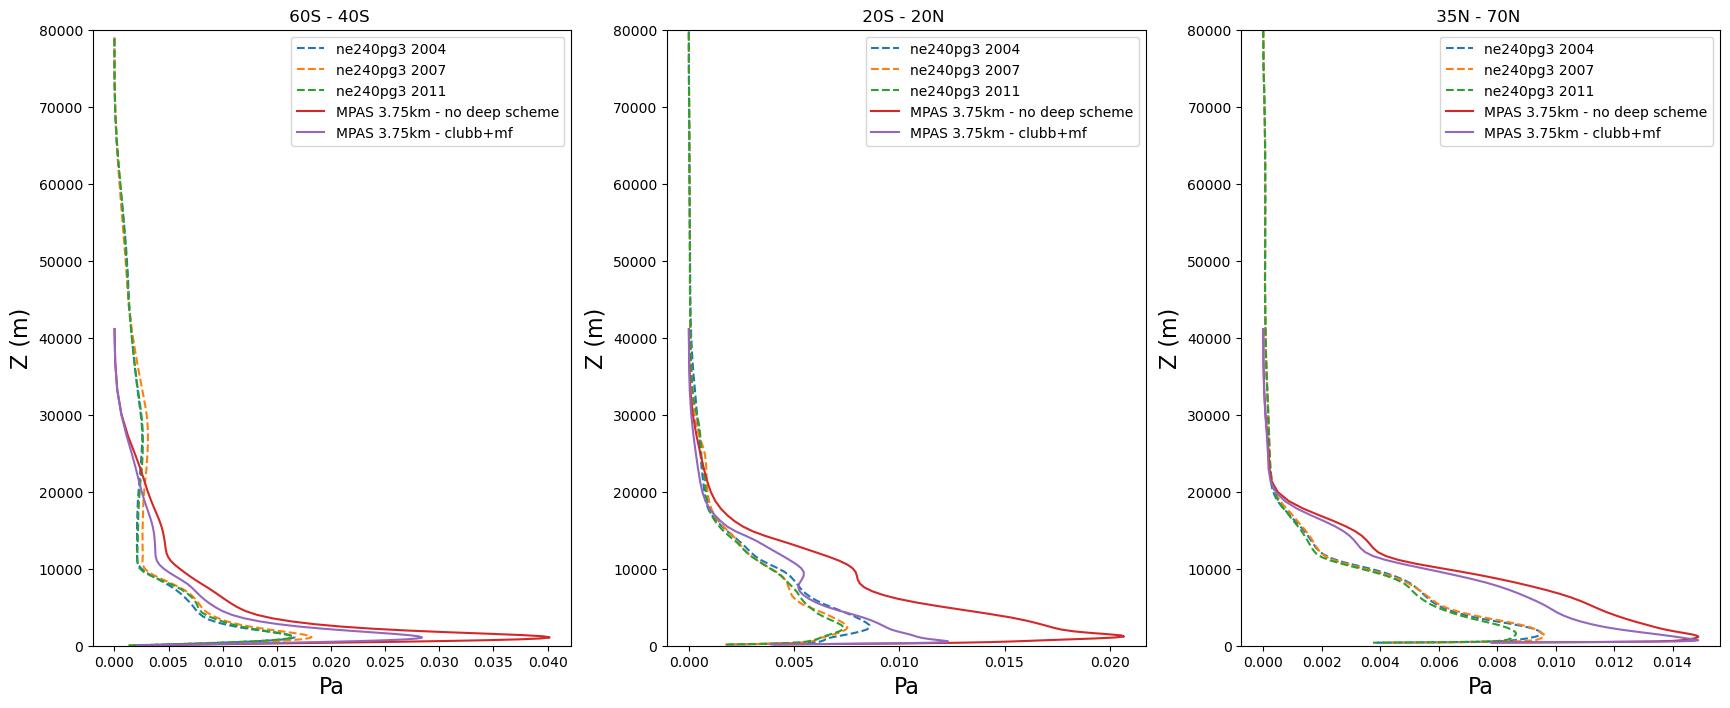

In [25]:
import event_io as eio
lats= [ [-60.,-40.] , [-20.,20.] , [35.,70.] ]

nplo=len( lats )

linest = [ "--","--","--","-","-"]

fig,axs=plt.subplots(1, nplo, figsize=( nplo*7,8) )
axs=axs.flatten()
p=0
for latr in lats:
    lat0,lat1=latr
    y0=np.argmin( np.abs( A.lat - lat0) )
    y1=np.argmin( np.abs( A.lat - lat1) )
    ax=axs[p]
    q=0
    for A in Al:
        nt,nz,nx,ny=np.shape( A.zo )
        Lat = np.tile(A.lat[None,:], (nz, 1) )
        Zoo = np.mean( A.zo[0,:,:,:], axis=2 )
        upwp_xv = np.mean( A.rho_epwp[0,:,:,:]  , axis=2 )
    
        coslat=np.cos( A.lat * np.pi/180. )
        CosLat=np.tile( coslat[ None, :] ,(nz,1) )
        cos_upwp_xv=CosLat*upwp_xv
        cos_Zoo =CosLat*Zoo
        
        momf_prof= np.mean(cos_upwp_xv[:,y0:y1],axis=1) / np.mean(CosLat[:,y0:y1],axis=1)
        z_prof   = np.mean(cos_Zoo[:,y0:y1],axis=1) / np.mean(CosLat[:,y0:y1],axis=1)
        
        ax.plot( momf_prof, z_prof, label=A.desc ,linestyle=linest[q] )
        ax.set_ylim(0.,80_000.)
        #ax.set_title( A.desc )
        ax.set_ylabel( 'Z (m)' , fontsize=16 )
        ax.set_xlabel( 'Pa', fontsize=16)
        #plt.colorbar(co)
        q=q+1
    ax.legend()
    latr_ = eio.pretty_lat(latr) 
    title= f" {latr_[0]} - {latr_[1]}  " 
    ax.set_title( title )
    p=p+1


38 19872.906006759258
38 19872.906006759258
38 19872.906006759258
8 19945.639649999997
8 19945.639649999997


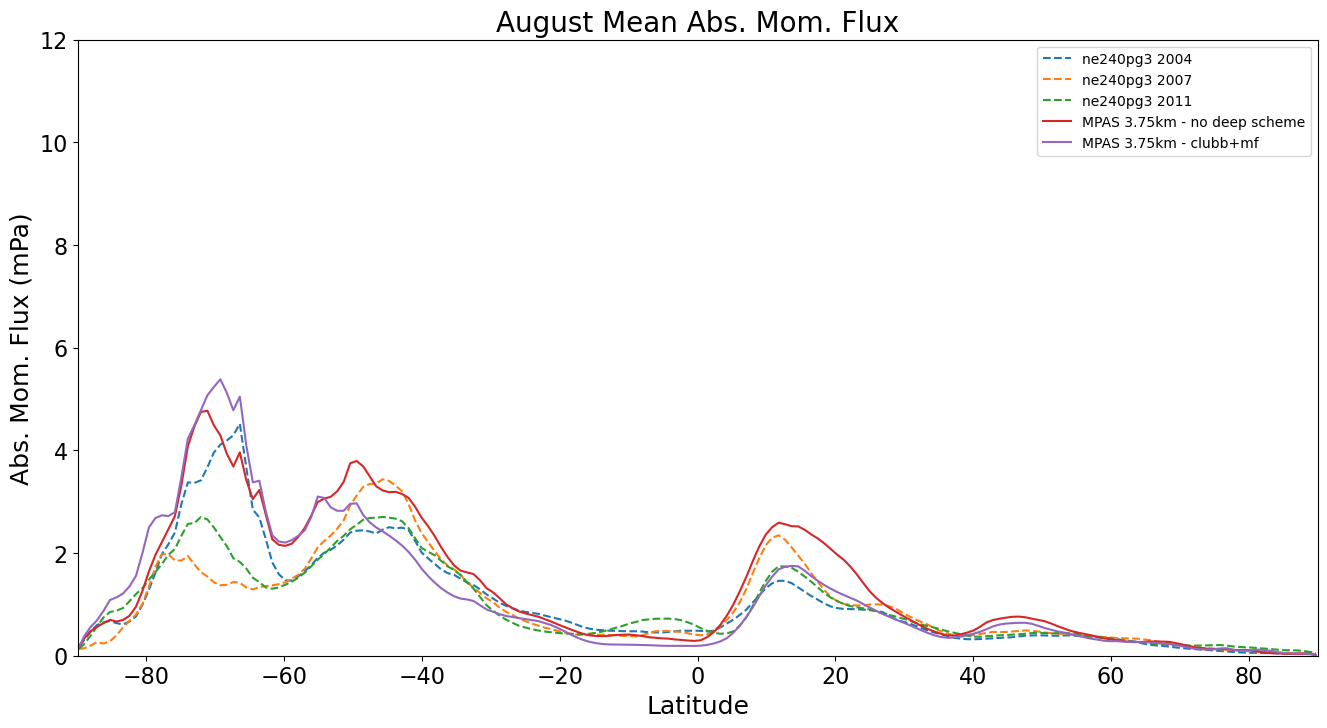

In [27]:
fig,ax=plt.subplots(figsize=( 16,8) )
p=0
zlev0=20_000.

linest = [ "--","--","--","-","-"]

q=0
for A in Al:
    nt,nz,nx,ny=np.shape( A.zo )
    Lat = np.tile(A.lat[None,:], (nz, 1) )
    Zoo = np.mean( A.zo[0,:,:,:], axis=2 )
    upwp_xv = np.mean( A.rho_epwp[0,:,:,:]  , axis=2 )
    z0=np.argmin( np.abs( A.zlev - zlev0) )

    print( z0, A.zlev[z0] )
    momf_prof = 1000.*upwp_xv[z0,:]
    
    ax.plot( A.lat, momf_prof, label=A.desc  , linestyle=linest[q] )
    #ax.set_ylim(0.,80_000.)
    #ax.set_title( A.desc )
    ax.set_xlabel( 'Latitude' , fontsize=18 )
    ax.set_ylabel( 'Abs. Mom. Flux (mPa)', fontsize=18)
    ax.set_ylim(0.,12.)
    ax.set_xlim(-90.,90.)
    ax.set_title("August Mean Abs. Mom. Flux",fontsize=20 )
    
    #plt.colorbar(co)
    q=q+1
    p=p+1
ax.tick_params(axis='both', labelsize=16)
ax.legend()


In [ ]:
print( poopypants )

[2.0e-05 4.0e-05 1.0e-04 2.0e-04 3.0e-04 4.0e-04 6.0e-04 8.0e-04 1.0e-03
 1.2e-03 1.6e-03 2.0e-03 3.0e-03 4.0e-03 6.0e-03 8.0e-03 1.0e-02 1.2e-02
 2.0e-02 4.0e-02 1.0e-01 2.0e-01]
(192,)
(93, 192)
(93, 192)
(192,)
(93, 192)
(93, 192)
(192,)
(93, 192)
(93, 192)
(192,)
(58, 192)
(58, 192)
(192,)
(58, 192)
(58, 192)


Text(0.5, 0.9, 'Zonal momentum vertical flux at 15.0 km')

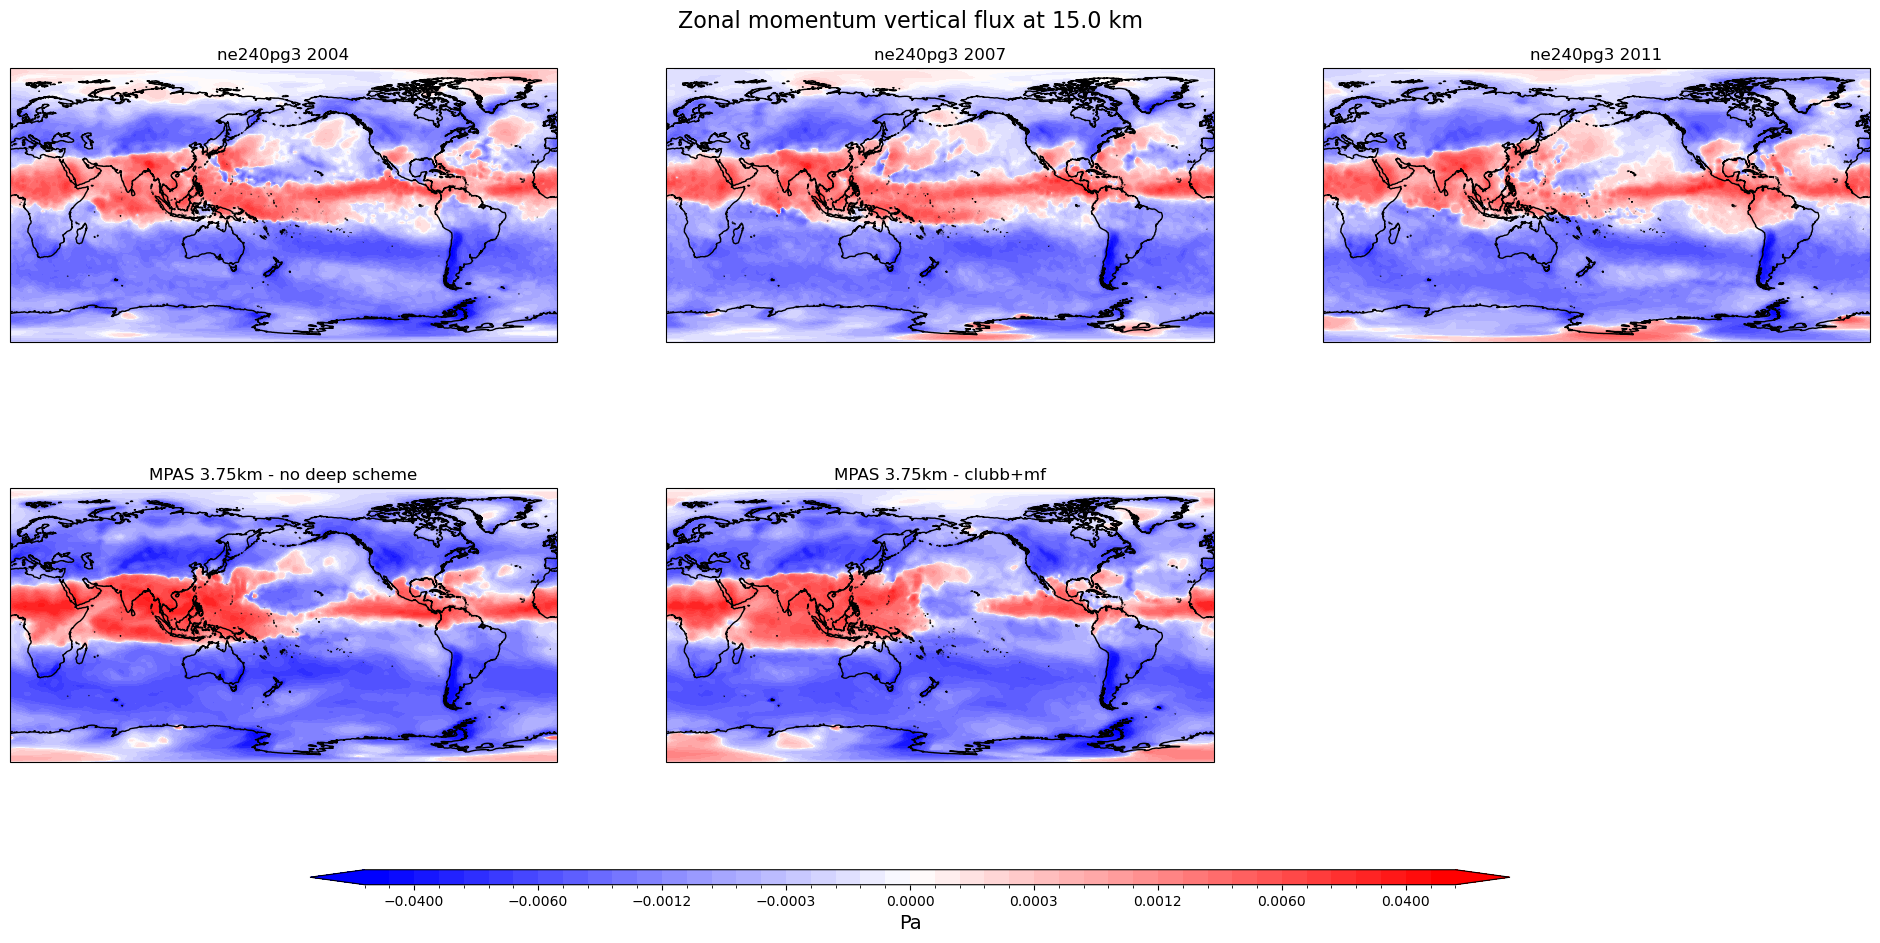

In [31]:
# Cartopy for pretty maps
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

MapProj = ccrs.PlateCarree(central_longitude=180.)
DataProj = ccrs.PlateCarree()


flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=0.2*np.asarray( flev )

print(flev)

flev2=np.flip( flev )
flev3 = np.concatenate( (-flev2, np.array([0]) , flev ))

cmap = plt.cm.bwr # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev3, ncolors=cmap.N, clip=False)



ulev=np.linspace(-100.,100.,num=21)
n=len(Al)
#fig,axs=plt.subplots(2,n//2+1, figsize=( (n//2+1)*7 , 12 ) )

fig, axs = plt.subplots(2, n//2+1, 
                        figsize=((n//2+1)*8, 10),
                        subplot_kw={"projection": MapProj})


axs[1,2].axis('off')

axs=axs.flatten()
p=0
zlev0=15_000.
for A in Al:
    ax=axs[p]
    nt,nz,nx,ny=np.shape( A.zo )
    Lat = np.tile(A.lat[None,:], (nz, 1) )
    Zoo = np.mean( A.zo[0,:,:,:], axis=2 )
    print( np.shape(A.lat) )
    print( np.shape(Lat) )
    print( np.shape(Zoo) )
    z0=np.argmin( np.abs( A.zlev - zlev0) )
            
    ax.coastlines(resolution='50m',color='black',linewidth=1 )

    #co=ax.contourf( A.lat, A.zlev, np.mean( A.rho_upwp[0,:,:,:], axis=2 ), levels=flev3, cmap=cmap , norm=norm, extend='both'  )
    #li=ax.contour( A.lat, A.zlev, np.mean( A.u[0,:,:,:], axis=2 ), levels=ulev, colors='black' , alpha=0.3)
    co=ax.contourf( A.lon,A.lat,A.rho_upwp[0,z0,:,:], levels=flev3, cmap=cmap , norm=norm, extend='both'  ,transform=DataProj )
    #li=ax.contour( Lat, Zoo, np.mean( A.u[0,:,:,:], axis=2 ), levels=ulev, colors='black' , alpha=0.3)
    ax.set_title( A.desc )
    ax.set_xlabel( 'Longitude' , fontsize=16 )
    ax.set_ylabel( 'Latitude', fontsize=16)
    #plt.colorbar(co)
    p=p+1

cax = fig.add_axes([0.25, 0.025, 0.50, 0.015])
cbar = fig.colorbar(
    co,
    cax=cax,
    orientation='horizontal')
cbar.set_label('Pa',fontsize=14)
fig.suptitle(f"Zonal momentum vertical flux at {zlev0/1_000} km", fontsize=16,y=0.9)

In [ ]:


flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=0.1*np.asarray( flev )
print(flev)


cmap = plt.cm.plasma # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)



ulev=np.linspace(-100.,100.,num=21)
n=len(Al)
fig,axs=plt.subplots(2,n//2+1, figsize=( (n//2+1)*8 , 12 ) )
axs[1,2].axis('off')

axs=axs.flatten()
p=0
for A in Al:
    ax=axs[p]
    co=ax.contourf( A.lat, A.zlev, np.mean( A.rho_epwp[0,:,:,:], axis=2 ), levels=flev, cmap=cmap , norm=norm, extend='both'  )
    li=ax.contour( A.lat, A.zlev, np.mean( A.u[0,:,:,:], axis=2 ), levels=ulev, colors='white' , alpha=0.3)
    ax.set_ylim(0.,25_000.)
    plt.colorbar(co)
    p=p+1

In [ ]:
zlev0=35_000. # 5_000.
z0=np.argmin( np.abs( A.zlev - zlev0 ) )
print(z0)
n=1
fig,ax=plt.subplots(1,n, figsize=( n*6 , 5 ) )
p=0
for A in Al:
    ax.plot(  A.lat, np.mean( A.rho_epwp[0,z0,:,:], axis=1 ) )

In [ ]:

zlev0=20_000. # 5_000.
z0=np.argmin( np.abs( A.zlev - zlev0 ) )

flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=0.05*np.asarray( flev )
print(flev)


cmap = plt.cm.plasma # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)



ulev=np.linspace(-100.,100.,num=21)
n=len(Al)
fig,axs=plt.subplots(2,n//2+1, figsize=( (n//2+1)*8 , 12 ) )
axs[1,2].axis('off')

axs=axs.flatten()
p=0
for A in Al:
    ax=axs[p]
    co=ax.contourf( A.lon, A.lat, A.rho_epwp[0,z0,:,:], levels=flev, cmap=cmap , norm=norm, extend='both'  )
    #li=ax.contour( A.lat, A.zlev, np.mean( A.u[0,:,:,:], axis=2 ), levels=ulev, colors='white' , alpha=0.3)
    #ax.set_ylim(0.,25_000.)
    plt.colorbar(co)
    p=p+1

In [ ]:
flev2=np.flip( flev )
flev3 = np.concatenate( (flev2, np.array([0]) , flev ))
print( flev3 )

In [ ]:

zlev0=35_000. # 5_000.
z0=np.argmin( np.abs( A.zlev - zlev0 ) )

flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=0.2*np.asarray( flev )

print(flev)

flev2=np.flip( flev )
flev3 = np.concatenate( (-flev2, np.array([0]) , flev ))

cmap = plt.cm.bwr # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev3, ncolors=cmap.N, clip=False)



ulev=np.linspace(-100.,100.,num=21)
n=len(Al)
fig,axs=plt.subplots(2,n//2+1, figsize=( (n//2+1)*8 , 12 ) )
axs[1,2].axis('off')

axs=axs.flatten()
p=0
for A in Al:
    ax=axs[p]
    co=ax.contourf( A.lon, A.lat, A.rho_upwp[0,z0,:,:], levels=flev3, cmap=cmap , norm=norm, extend='both'  )
    #li=ax.contour( A.lat, A.zlev, np.mean( A.u[0,:,:,:], axis=2 ), levels=ulev, colors='white' , alpha=0.3)
    #ax.set_ylim(0.,25_000.)
    plt.colorbar(co)
    p=p+1

In [ ]:
lat0,lon0=0.,180.
y=np.argmin( np.abs( A.lat - lat0 ) )
x=np.argmin( np.abs( A.lon - lon0 ) )

for A in Al:
    plt.plot( A.rho[0,:,y,x] , A.zlev )